In [22]:
# =============================================================================
# 1. IMPORTS AND SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2
import os
import sys
import pathlib
import re
import gc
import yaml
import warnings
import time
from multiprocessing import Pool, cpu_count

# Suppress warnings
warnings.filterwarnings("ignore")

# --- Environment and JAX Configuration ---
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
from jax.lib import xla_bridge
import jax.numpy as jnp
import jax_cosmo.background as bkgrd

# platform = xla_bridge.get_backend().platform
try:
    platform = xla_bridge.get_backend().platform
except:
    from jax.extend import backend
    platform = backend.get_backend().platform
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
print(f"JAX backend: {platform}, Total devices: {jax.device_count()}, Local devices: {jax.local_device_count()}")

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()

# --- Library Imports ---
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
# import asdf
import healpy as hp
from tqdm import tqdm
import pickle as pk
import h5py as h5

# --- Matplotlib Configuration ---
plt.rcParams['text.usetex'] = True

# --- Add Project-Specific Paths ---
curr_path = pathlib.Path().absolute()
project_base = curr_path.parents[1] 
abs_path_data = project_base / "data"
abs_path_src = project_base / "src"
abs_path_results = project_base / "results"
abs_path_params = project_base / "param_files"

for path in [curr_path, abs_path_data, abs_path_src, abs_path_results, abs_path_params]:
    sys.path.append(str(path))

# --- Import Custom Modules ---
from get_radial_profiles import Profiles
from get_sim_maps import setup_sim_map, get_sim_map
import helpers.constants as constants




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
JAX backend: gpu, Total devices: 1, Local devices: 1


In [23]:
# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================
from halo_processing_utils import process_halo

def split_array_power_ratio(arr, num_parts, power_val=0.5):
    """Splits an array into parts with sizes proportional to j^power_val."""
    n_total = arr.shape[0]
    j_values = np.arange(1, num_parts + 1)
    weights = j_values**power_val
    sum_of_weights = np.sum(weights)
    ideal_sizes = (n_total / sum_of_weights) * weights
    
    int_sizes = np.floor(ideal_sizes).astype(int)
    remainder = n_total - np.sum(int_sizes)
    
    # Distribute remainder based on fractional parts
    fractional_parts = ideal_sizes - int_sizes
    indices_to_increment = np.argsort(fractional_parts)[-remainder:]
    int_sizes[indices_to_increment] += 1
    
    split_indices = np.cumsum(int_sizes)[:-1]
    return np.split(arr, split_indices)

def read_yaml(file_path):
    """Reads a YAML file and returns its content."""
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def generate_dicts(data):
    """Extracts parameter dictionaries from the main data dictionary."""
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# --- Functions for Parallel Halo Processing ---

def open_data(file, Mlim=1e8):
    df = h5.File(ldir+file, 'r')
    M200c = df['M200c'][()]
    X, Y, Z = df['X'][()], df['Y'][()], df['Z'][()]
    VX, VY, VZ = df['VX'][()], df['VY'][()], df['VZ'][()]
    if (M200c.shape) is not None:
        indsel = np.where(M200c>Mlim)[0]
        X_val = X[indsel]
        Y_val = Y[indsel]
        Z_val = Z[indsel]
        M200c_val = M200c[indsel]
        VX_val = VX[indsel]
        VY_val = VY[indsel]
        VZ_val = VZ[indsel]
        Vlos = (VX_val*X_val + VY_val*Y_val + VZ_val*Z_val)/np.sqrt(X_val**2 + Y_val**2 + Z_val**2)
    else:
        X_val = np.array([])
        Y_val = np.array([])
        Z_val = np.array([])
        M200c_val = np.array([])
        VX_val = np.array([])
        VY_val = np.array([])
        VZ_val = np.array([])
        Vlos = np.array([])
    df.close()
    return (X_val, Y_val, Z_val, Vlos, M200c_val)

def concatenate_data(results):
    # Pre-compute lengths for each part
    lengths = np.array([len(result[0]) for result in results])
    total_length = lengths.sum()

    # Pre-allocate arrays
    X_all = np.empty(total_length)
    Y_all = np.empty(total_length)
    Z_all = np.empty(total_length)
    Vlos_all = np.empty(total_length)
    M200_all = np.empty(total_length)

    # Calculate start and end indices
    end_ind_all = np.cumsum(lengths)
    start_ind_all = np.roll(end_ind_all, 1)
    start_ind_all[0] = 0


    # Use array slicing for assignment
    for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
        X_all[start:end] = result[0]
        Y_all[start:end] = result[1]
        Z_all[start:end] = result[2]
        Vlos_all[start:end] = result[3]
        M200_all[start:end] = result[4]

    return X_all, Y_all, Z_all, Vlos_all, M200_all

def concatenate_batch_results(results, M_all_chunk, z_all_chunk, vlos_all_chunk, halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype):
    """Concatenates results from a single batch of parallel processing."""
    if not results:
        return None
        
    lengths = np.array([res[3] for res in results], dtype=np.int32)
    total_length = lengths.sum()
    
    # Pre-allocate arrays for efficiency
    nearby_pix_all = np.empty(total_length, dtype=pixel_dtype)
    distances_pix_all = np.empty(total_length, dtype=np.float32)
    halo_indices = np.empty(total_length, dtype=np.int32)
    
    end_indices = np.cumsum(lengths)
    start_indices = np.concatenate([[0], end_indices[:-1]])
    
    for i, (start, end, res) in enumerate(zip(start_indices, end_indices, results)):
        nearby_pix_all[start:end] = res[0]
        distances_pix_all[start:end] = res[1]
        halo_indices[start:end] = res[2]
    
    original_halo_indices = np.array([res[2] for res in results], dtype=np.int32)
    
    # Map pixel-level properties back from halo-level properties
    logM_ind_all = np.log(M_all_chunk[halo_indices]).astype(np.float32)
    z_ind_all = z_all_chunk[halo_indices].astype(np.float32)
    vlos_ind_all = vlos_all_chunk[halo_indices].astype(np.float32)
    
    # Map halo-level properties
    ang_distance_all = halo_cat_DV_np[original_halo_indices].astype(np.float32)
    rp_max_all = (max_paint_R200c_factor * halo_cat_R200c_np[original_halo_indices]).astype(np.float32)
    
    return (nearby_pix_all, distances_pix_all, start_indices, end_indices, 
            logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all)

def final_concatenate_batches(all_results, pixel_dtype):
    """Final concatenation of results from all batches."""
    total_pix = sum(len(res[0]) for res in all_results)
    total_halos = sum(len(res[2]) for res in all_results)
    
    # Pre-allocate final arrays
    final_nearby_pix = np.empty(total_pix, dtype=pixel_dtype)
    final_distances = np.empty(total_pix, dtype=np.float32)
    final_logM = np.empty(total_pix, dtype=np.float32)
    final_z = np.empty(total_pix, dtype=np.float32)
    final_vlos = np.empty(total_pix, dtype=np.float32)
    final_start_ind = np.empty(total_halos, dtype=np.int32)
    final_end_ind = np.empty(total_halos, dtype=np.int32)
    final_ang_dist = np.empty(total_halos, dtype=np.float32)
    final_rp_max = np.empty(total_halos, dtype=np.float32)
    
    pix_offset, halo_offset = 0, 0
    for result in all_results:
        n_pix_batch = len(result[0])
        n_halo_batch = len(result[2])
        
        # Unpack batch results
        nearby_pix_b, dist_b, start_b, end_b, logM_b, z_b, vlos_b, ang_dist_b, rp_max_b = result
        
        # Fill pixel-level arrays
        final_nearby_pix[pix_offset : pix_offset + n_pix_batch] = nearby_pix_b
        final_distances[pix_offset : pix_offset + n_pix_batch] = dist_b
        final_logM[pix_offset : pix_offset + n_pix_batch] = logM_b
        final_z[pix_offset : pix_offset + n_pix_batch] = z_b
        final_vlos[pix_offset : pix_offset + n_pix_batch] = vlos_b
        
        # Fill halo-level arrays, adjusting indices with the offset
        final_start_ind[halo_offset : halo_offset + n_halo_batch] = start_b + pix_offset
        final_end_ind[halo_offset : halo_offset + n_halo_batch] = end_b + pix_offset
        final_ang_dist[halo_offset : halo_offset + n_halo_batch] = ang_dist_b
        final_rp_max[halo_offset : halo_offset + n_halo_batch] = rp_max_b
        
        pix_offset += n_pix_batch
        halo_offset += n_halo_batch
        
    return (final_nearby_pix, final_distances, final_start_ind, final_end_ind,
            final_logM, final_z, final_vlos, final_ang_dist, final_rp_max)

def process_halos_in_batches(M_all_chunk, ra_all_chunk, dec_all_chunk, z_all_chunk, vlos_all_chunk, 
                             halo_cat_R200c, halo_cat_DA, max_paint_R200c_factor, nside, batch_size=1000):
    """Manages the parallel processing of halos in manageable batches."""
    pixel_dtype = np.int32 if nside <= 8192 else np.int64
    
    ra_all_np = np.clip(np.array(ra_all_chunk, dtype=np.float32), 0.01, 359.99)
    dec_all_np = np.clip(np.array(dec_all_chunk, dtype=np.float32), -89.99, 89.99)
    halo_cat_R200c_np = np.array(halo_cat_R200c, dtype=np.float32)
    halo_cat_DV_np = np.array(halo_cat_DA, dtype=np.float32)
    
    n_halos = len(z_all_chunk)
    all_results = []
    
    with Pool(cpu_count()) as pool:
        for batch_start in range(0, n_halos, batch_size):
            batch_end = min(batch_start + batch_size, n_halos)
            print(f"Processing halo batch {batch_start//batch_size + 1}/{(n_halos - 1)//batch_size + 1}...")
            
            # Create arguments for each halo in the batch
            batch_args = [(jhalo, ra_all_np, dec_all_np, halo_cat_R200c_np, halo_cat_DV_np, 
                           max_paint_R200c_factor, nside, pixel_dtype) for jhalo in range(batch_start, batch_end)]
            
            # Map processing to the pool
            batch_results = pool.map(process_halo, batch_args)
            batch_results = [r for r in batch_results if r is not None]
            
            if batch_results:
                # Concatenate results from the current batch
                batch_data = concatenate_batch_results(batch_results, M_all_chunk, z_all_chunk, vlos_all_chunk, 
                                                       halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype)
                if batch_data is not None:
                    all_results.append(batch_data)
            
            del batch_results, batch_args
            gc.collect()
    
    if not all_results:
        return None
        
    return final_concatenate_batches(all_results, pixel_dtype)



In [41]:
import yaml
import pathlib
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const

curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# new_data = read_yaml(abs_path_params + '/xCMASS/params_fit_test.yaml')
new_data = read_yaml(abs_path_params + '/pasting/params.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

from scipy.interpolate import interp1d
ks = np.geomspace(3e-1,10,10) # wavenumbers
# zarray_lens = np.linspace(0.001, 1.6, 200)
zarray_lens = np.linspace(0.001, 0.8, 40)

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)

# import asdf
# z_array = np.linspace(0, 1.5, 200)
# z_centers = 0.5 * (z_array[1:] + z_array[:-1])
zvals = [0.5]
nbins_lens = len(zvals)
# zarray_lens_edges = 
delta_zarray = zarray_lens[1] - zarray_lens[0]
zarray_lens_edges = np.concatenate(([zarray_lens[0] - delta_zarray/2], 0.5*(zarray_lens[1:] + zarray_lens[:-1]), [zarray_lens[-1] + delta_zarray/2]))
nz_comoving_all = np.zeros((len(zvals), len(zarray_lens)))
nz_lens = {}
nbar_all = []
Ngals_bins = []
for jz, zval in enumerate(zvals):
    df = pk.load(open(f"{abs_path_data}/CMASS/measure_cmass_planck.pk", 'rb'))
    
    # zmin = df['zmin']
    # zmax = df['zmax']
    zmin = 0.005
    zmax = 0.3
    # chi_min = radial_comoving_distance(cosmo_jax, 1.0/(1.0 + zmin))
    # chi_max = radial_comoving_distance(cosmo_jax, 1.0/(1.0 + zmax))

    # comoving_volume = (4.0/3.0) * np.pi * (chi_max**3 - chi_min**3) * (1/8.)
    # nbar = df['Ngal'] / comoving_volume  # in (Mpc/h)^-3
    nbar = 0.00005
    nbar_all.append(nbar)

    # zcen, nz_f = df['zcen'], df['nz']
    zmin_max = np.linspace(0.1, 0.351, 21)
    zcen = 0.5*(zmin_max[1:] + zmin_max[:-1])
    
    # nz_f = 0.001*np.ones_like(zcen)
    nz_f = (4/3.)*jnp.pi*(radial_comoving_distance(cosmo_jax, 1.0/(1.0 + zmin_max[1:]))**3 - radial_comoving_distance(cosmo_jax, 1.0/(1.0 + zmin_max[:-1]))**3)
    nz_f = np.array(nz_f)
    indsel = np.where((zcen < zmin) | (zcen > zmax))[0]
    nz_f[indsel] = 0.0
    nz_f_norm = nz_f / (np.trapz(nz_f, zcen))
    nz_f_norm_interp = interp1d(zcen, nz_f_norm, fill_value=0.0, bounds_error=False)
    hist_z = nz_f_norm_interp(zarray_lens)
    nz_lens[jz] = hist_z

    nz_comoving = np.zeros_like(zarray_lens)
    indsel = np.where(hist_z > 1e-5)[0]
    nz_comoving[indsel] = nbar
    nz_comoving_all[jz] = nz_comoving

analysis_dict['nbar_gal_comoving_zarray'] = zarray_lens
analysis_dict['nbar_gal_comoving_val'] = np.sum(np.array(nz_comoving_all), axis=0)

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-10)
analysis_dict['nz_lens_info_dict'] = nz_info_dict


analysis_dict['is_cmb_lensing'] = True
from astropy.io import fits
# df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
# z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = jnp.ones(1)
nz_info_dict['nbins'] = 1
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = jnp.ones(1)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = jnp.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = jnp.zeros(analysis_dict['nz_source_info_dict']['nbins'])

# analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True

# # Override halo parameters for this analysis
halo_params_dict.update({
    'rmin': 0.005, 'rmax': 10.0, 'nr': 48,
    'zmin': 0.005, 'zmax': 0.8, 'nz':31,
    'lg10_Mmin': 14.0, 'lg10_Mmax': 15.75, 'nM': 32
})

# cosmology of the backlight simulations
cosmo_params_dict = {'w0': -1.0, 'flat': True, 'H0': 67.11, 'Om0': 0.3175, 
                        'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624}

sim_params_dict['cosmo'] = cosmo_params_dict

# Prof_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)



In [25]:
# --- Timing Flag ---
PROFILE_TIMING = True
# PROFILE_TIMING = False

if PROFILE_TIMING:
    script_start_time = time.perf_counter()
    
# --- Analysis Parameters ---
# nside = 1024
nside = 512
jdevice = 0
Ndevices = 1

# --- Load Configuration and Initialize Models ---
if PROFILE_TIMING:
    setup_start_time = time.perf_counter()




In [42]:
from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)




(100, 3000.0)

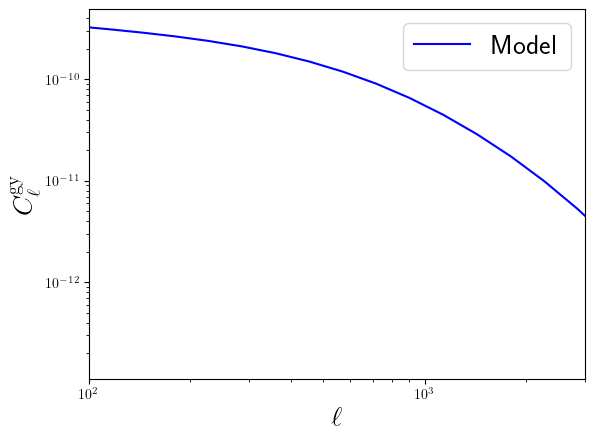

In [45]:
plt.figure
plt.plot(Cls_test.ell_array, Cls_test.Cl_gal_y_tot_mat[:,0], color='blue', label=r'Model')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{\mathrm{gy}}$', fontsize=20)
plt.legend(fontsize=20)
plt.xlim(100, 3e3)
# plt.ylim(1e-5, 1e-2)




(100, 3000.0)

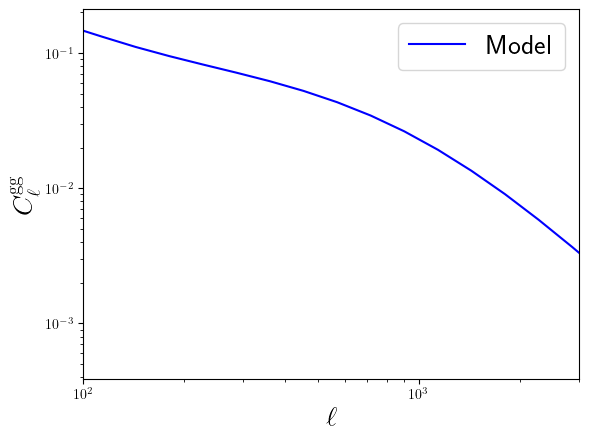

In [46]:
plt.figure
plt.plot(Cls_test.ell_array, Cls_test.Cl_gal_tau_tot_mat[:,0], color='blue', label=r'Model')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
plt.legend(fontsize=20)
plt.xlim(100, 3e3)




(1e-05, 0.01)

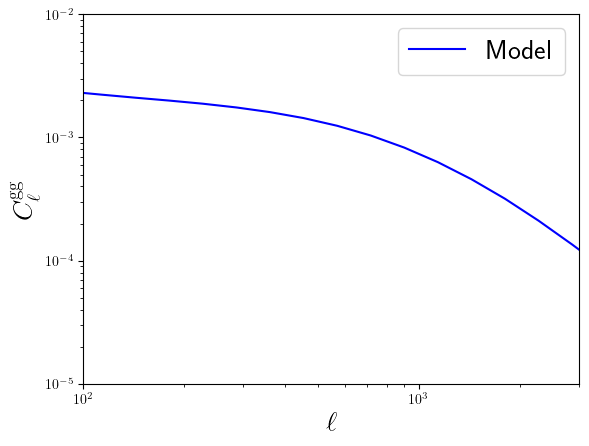

In [47]:
plt.figure
plt.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,0,0], color='blue', label=r'Model')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
plt.legend(fontsize=20)
plt.xlim(100, 3e3)
plt.ylim(1e-5, 1e-2)




In [ ]:
# Setup simulated map generation. This also pre-computes some necessary 2D projection of the profiles needed for pasting
mock_params_dict_setup = {}
mock_params_dict_setup['nside'] = nside
mock_params_dict_setup['get_ymap'] = True
mock_params_dict_setup['get_kSZmap'] = True
mock_params_dict_setup['get_taumap'] = True
mock_params_dict_setup['get_kappamap'] = True
mock_params_dict_setup['get_galmap'] = True
mock_params_dict_setup['smooth_profiles'] = True
Prof_test = setup_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict_setup, Profiles_obj=profiles_test)

chi2z_interp = interpolate.interp1d(np.log(Prof_test.chi_array), Prof_test.z_array, fill_value="extrapolate")

if PROFILE_TIMING:
    setup_end_time = time.perf_counter()
    print(f"\n[PROFILE] Initial setup time: {setup_end_time - setup_start_time:.2f} seconds")






[PROFILE] Initial setup time: 1066.94 seconds


In [ ]:
# --- Loop Over Each Redshift Slice ---
sdir = f'{abs_path_data}/backlight'
os.makedirs(sdir, exist_ok=True)
save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_split{jdevice}of{Ndevices}_paste_testlowmass.pkl'
# Load halo data
if PROFILE_TIMING:
    load_start_time = time.perf_counter()


# Calculate RA, DEC, and v_los & Apply selections
if PROFILE_TIMING:
    selection_start_time = time.perf_counter()
    
halo_file = h5.File(f'{sdir}/halo_catalog_Mlim_1e14_zlim_0.4.h5', 'r')
ra_all = halo_file['ra'][()]
dec_all = halo_file['dec'][()]
z_all = halo_file['z'][()]
M200c_all = halo_file['M200c'][()]
vlos_all = halo_file['vlos'][()]

print(f"Number of halos for this device: {len(M200c_all)}")
print(f"Min, Mean, Max log10(M200c): {np.min(np.log10(M200c_all)):.2f}, {np.mean(np.log10(M200c_all)):.2f}, {np.max(np.log10(M200c_all)):.2f}, Mean z: {np.mean(z_all):.2f}")

# --- Chunking and Map Generation ---
nh_max_map = {8192: 4e3, 4096: 5e4, 2048: 5e5, 1024: 1e7, 512: 5e7}
nh_max = nh_max_map.get(nside, 1e5) # Default if nside not in map
nsel = len(M200c_all)
num_chunks = int(np.ceil(nsel / nh_max)) if nsel > nh_max else 1

map_rhom, map_ymap, map_ksz, map_tau = (np.zeros(12 * nside**2, dtype=np.float32) for _ in range(4))
mock_gals_all = {}

for i in tqdm(range(num_chunks)):
    # start, end = int(i * nh_max), int((i + 1) * nh_max)
    start, end = 0, len(ra_all)
    M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk = (
        M200c_all[start:end], ra_all[start:end], dec_all[start:end],
        z_all[start:end], vlos_all[start:end]
    )
    
    scale_fac = 1. / (1. + z_chunk)
    rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(Prof_test.cosmo_jax, scale_fac) * 1e9
    rho_treshold = 200 * rho_c_z
    R200c = (M_chunk * 3.0 / (4.0 * jnp.pi * rho_treshold))**(1.0 / 3.0)
    DA = bkgrd.angular_diameter_distance(Prof_test.cosmo_jax, scale_fac)
    
    if PROFILE_TIMING:
        pixel_finding_start_time = time.perf_counter()
    
    max_paint_R200c_factor = 1.0
    # batch_size = int(nh_max // 2) if nh_max > 2 else 1
    batch_size = len(ra_all)
    result = process_halos_in_batches(
        M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk,
        R200c, DA, max_paint_R200c_factor, nside, batch_size
    )
    
    if PROFILE_TIMING:
        pixel_finding_end_time = time.perf_counter()
        print(f"\n[PROFILE] Chunk {i+1}/{num_chunks} - Pixel finding: {pixel_finding_end_time - pixel_finding_start_time:.2f} seconds")
    
    if result:
        mock_params_dict = {
            **mock_params_dict_setup,
            'halo_z': jnp.array(z_chunk, dtype=jnp.float32),
            'halo_ra': jnp.array(ra_chunk, dtype=jnp.float32),
            'halo_dec': jnp.array(dec_chunk, dtype=jnp.float32),
            'halo_M': jnp.array(M_chunk, dtype=jnp.float64),
            'halo_vlos': jnp.array(vlos_chunk, dtype=jnp.float32),
            'nearby_pix_all': jnp.array(result[0]),
            'start_ind': jnp.array(result[2], dtype=jnp.int32),
            'end_ind': jnp.array(result[3], dtype=jnp.int32),
            'pix_prop_all': (jnp.array([np.log(result[1]), result[5], result[4], result[6]]).T).astype(jnp.float32),
            'ang_distance_all': jnp.array(result[7]),
            'rp_max_all': jnp.array(result[8]),
            'profile_timing': PROFILE_TIMING
        }
        
        if PROFILE_TIMING:
            map_gen_start_time = time.perf_counter()
        
        mock_map = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=Prof_test)
        
        map_rhom += np.nan_to_num(mock_map.rhommap_final)
        map_ymap += np.nan_to_num(mock_map.ymap_final)
        map_ksz += np.nan_to_num(mock_map.kszmap_final)
        map_tau += np.nan_to_num(mock_map.taumap_final)
        mock_gals_all[i] = mock_map.final_galaxy_catalog
        print(mock_gals_all[i].shape)

        if PROFILE_TIMING:
            map_gen_end_time = time.perf_counter()
            print(f"[PROFILE] Chunk {i+1}/{num_chunks} - JAX map generation: {map_gen_end_time - map_gen_start_time:.2f} seconds")
        
        # del mock_map, mock_params_dict, result
        jax.clear_caches()
        gc.collect()

# Save results for the current redshift slice
if PROFILE_TIMING:
    save_start_time = time.perf_counter()
    

saved_data = {'mock_gals_all': mock_gals_all, 'map_rhom': map_rhom, 
                'map_ymap': map_ymap, 'map_ksz': map_ksz, 'map_tau': map_tau}

with open(save_map_fname, 'wb') as f:
    pk.dump(saved_data, f)

del saved_data, mock_gals_all
gc.collect()




Number of halos for this device: 83372
Min, Mean, Max log10(M200c): 14.00, 14.21, 15.31, Mean z: 0.29


  0%|          | 0/1 [00:00<?, ?it/s]

Processing halo batch 1/1...

[PROFILE] Chunk 1/1 - Pixel finding: 3.39 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 1.0404 seconds
setup_tau_interpolator             : 0.3117 seconds
ymap_generation_and_assembly       : 1.6220 seconds
ksz_map_generation_and_assembly    : 1.3818 seconds
tau_map_generation_and_assembly    : 1.2064 seconds
kappa_map_generation_and_assembly  : 1.2884 seconds
galaxy_ppf_interpolator_creation   : 0.2000 seconds
galaxy_population                  : 5.1616 seconds
galaxy_catalog_filtering           : 0.4925 seconds
total_execution                    : 12.7207 seconds
---------------------------------------

(398914, 6)
[PROFILE] Chunk 1/1 - JAX map generation: 12.77 seconds


100%|██████████| 1/1 [00:18<00:00, 18.56s/it]


0

In [53]:
import healpy as hp
saved_data = pk.load(open(save_map_fname, 'rb'))
mock_gals_all = saved_data['mock_gals_all']
gal_ra_all = mock_gals_all[0][:,0]
gal_dec_all = mock_gals_all[0][:,1]
gal_z_all = mock_gals_all[0][:, 2]
indsel_z = np.where((gal_z_all < 0.31) & (gal_z_all > 0.1))[0]
halo_mass_all_gal = mock_gals_all[0][:, 3]
is_cen_all = mock_gals_all[0][:, 4]
map_gal = np.zeros(12 * nside**2, dtype=np.float32)
pix_gal = hp.ang2pix(nside, gal_ra_all[indsel_z], gal_dec_all[indsel_z], lonlat=True)
np.add.at(map_gal, pix_gal, 1.)
# map_gal = hp.ud_grade(map_gal, nside_out=128)





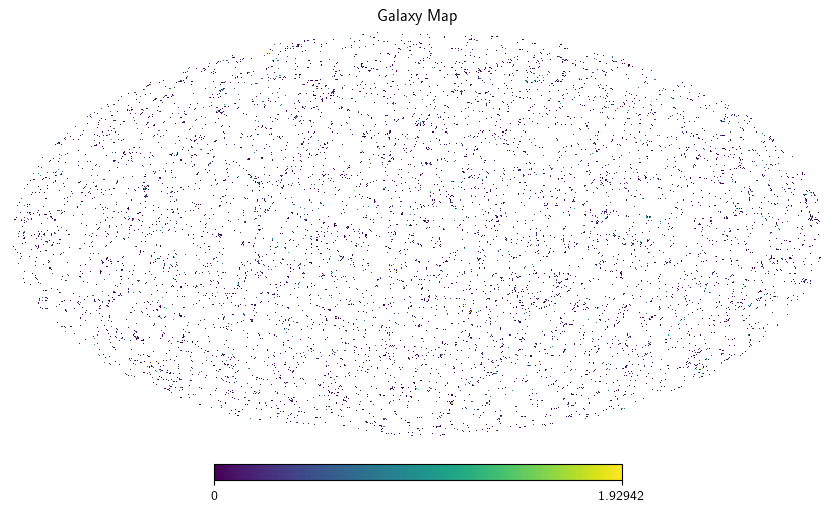

In [54]:
hp.mollview(np.log10(map_gal), title=fr'Galaxy Map')



(100, 1000)

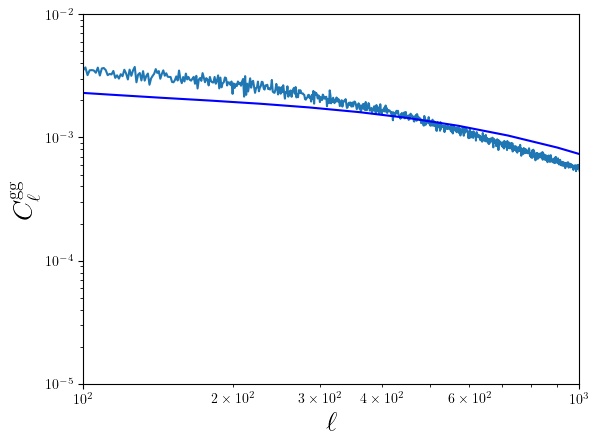

In [70]:
delta_map_gal = map_gal/np.mean(map_gal)
Cl_gg = hp.anafast(delta_map_gal)
plt.figure()
plt.plot(np.arange(len(Cl_gg)),Cl_gg/(hp.pixwin(nside)**2))
plt.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,0,0], color='blue', label=r'Model')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
plt.ylim(1e-5, 1e-2)
plt.xlim(100, 1000)




(100, 1000)

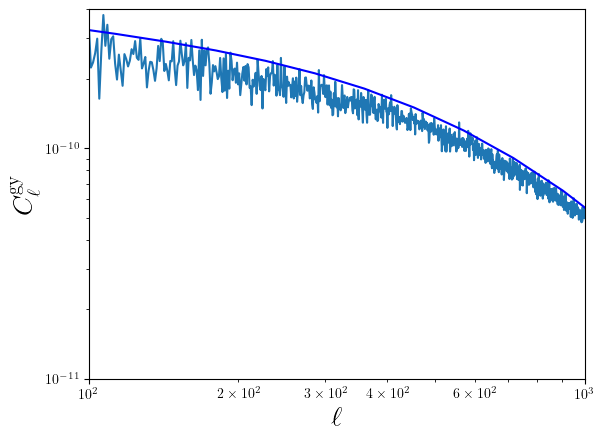

In [71]:
import healpy as hp
saved_data = pk.load(open(save_map_fname, 'rb'))
# print(saved_data.keys())
map_tSZ = saved_data['map_ymap']
map_tau = saved_data['map_tau']
mock_gals_all = saved_data['mock_gals_all']
gal_ra_all = mock_gals_all[0][:,0]
gal_dec_all = mock_gals_all[0][:,1]
gal_z_all = mock_gals_all[0][:, 2]
# indsel_z = np.where(gal_z_all < 0.31)[0]
indsel_z = np.where((gal_z_all < 0.31) & (gal_z_all > 0.1))[0]
map_gal = np.zeros(12 * nside**2, dtype=np.float32)
pix_gal = hp.ang2pix(nside, gal_ra_all[indsel_z], gal_dec_all[indsel_z], lonlat=True)
np.add.at(map_gal, pix_gal, 1.)
delta_gal = map_gal/np.mean(map_gal)
Cl_gy = hp.anafast(delta_gal, map_tSZ)


plt.figure()
plt.plot(np.arange(len(Cl_gy)), Cl_gy/(hp.pixwin(nside)**2))
plt.plot(Cls_test.ell_array, Cls_test.Cl_gal_y_tot_mat[:,0], color='blue', label=r'Model')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell^{\mathrm{gy}}$', fontsize=20)
plt.ylim(1e-11, 4e-10)
plt.xlim(100, 1000)




In [79]:
# import healpy as hp
# saved_data = pk.load(open(save_map_fname, 'rb'))
# # print(saved_data.keys())
# map_tSZ = saved_data['map_ymap']
# map_tau = saved_data['map_tau']
# mock_gals_all = saved_data['mock_gals_all']
# gal_ra_all = mock_gals_all[0][:,0]
# gal_dec_all = mock_gals_all[0][:,1]
# gal_z_all = mock_gals_all[0][:, 2]
# # indsel_z = np.where(gal_z_all < 0.31)[0]
# indsel_z = np.where((gal_z_all < 0.31) & (gal_z_all > 0.1))[0]
# map_gal = np.zeros(12 * nside**2, dtype=np.float32)
# pix_gal = hp.ang2pix(nside, gal_ra_all[indsel_z], gal_dec_all[indsel_z], lonlat=True)
# np.add.at(map_gal, pix_gal, 1.)
# delta_gal = map_gal/np.mean(map_gal)
# Cl_gtau = hp.anafast(delta_gal, map_tau)


# plt.figure()
# plt.plot(np.arange(len(Cl_gtau)), Cl_gtau/(hp.pixwin(nside)**2))
# plt.plot(Cls_test.ell_array, 2e-7*Cls_test.Cl_gal_tau_tot_mat[:,0], color='blue', label=r'Model')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel(r'$\ell$', fontsize=20)
# plt.ylabel(r'$C_\ell^{\mathrm{g\tau}}$', fontsize=20)
# plt.ylim(1e-9, 1e-7)
# plt.xlim(100, 1000)



In [67]:
# zmin_cv = 0.25
# zmax_cv = 0.3
import jax.scipy.integrate as jsi
zmin_max_cv_array = np.linspace(0.0, 0.5, 15)
zmin_cv_array = zmin_max_cv_array[:-1]
zmax_cv_array = zmin_max_cv_array[1:]
zcen_cv_array = 0.5*(zmin_cv_array + zmax_cv_array)
ngal_cv_array = np.zeros_like(zmin_cv_array)
ncen_cv_array = np.zeros_like(zmin_cv_array)
nsat_cv_array = np.zeros_like(zmin_cv_array)

ngal_cv_array_th = np.zeros_like(zmin_cv_array)
ncen_cv_array_th = np.zeros_like(zmin_cv_array)
nsat_cv_array_th = np.zeros_like(zmin_cv_array)


for jz in range(len(zmin_cv_array)):
    zmin_cv = zmin_cv_array[jz]
    zmax_cv = zmax_cv_array[jz]
    chi_min_cv = bkgrd.radial_comoving_distance(Prof_test.cosmo_jax, 1/(1 + zmin_cv))
    chi_max_cv = bkgrd.radial_comoving_distance(Prof_test.cosmo_jax, 1/(1 + zmax_cv))
    Vol_cv = (4/3)*jnp.pi*(chi_max_cv**3 - chi_min_cv**3)
    gal_z_all = np.array(gal_z_all)
    indzel_gal = np.where((gal_z_all > zmin_cv) & (gal_z_all < zmax_cv))[0]
    Ngal_cv = len(indzel_gal)
    iscen_all_sel = is_cen_all[indzel_gal]
    Ncen_cv = len(np.where(iscen_all_sel > 0)[0])
    Nsat_cv = len(np.where(iscen_all_sel < 1)[0])
    # print(Ncen_cv, Nsat_cv, iscen_all_sel)

    ngal_cv_array[jz] = (Ngal_cv/Vol_cv)[0]
    ncen_cv_array[jz] = (Ncen_cv/Vol_cv)[0]
    nsat_cv_array[jz] = (Nsat_cv/Vol_cv)[0]

    jz_test = np.argmin(np.abs(Cls_test.z_array - zcen_cv_array[jz]))
    Ncen_mat_theory = Cls_test.Ncen_mat[jz_test,...]
    Nsat_mat_theory = Cls_test.Nsat_mat[jz_test,...]
    Ntot_mat = (Ncen_mat_theory + Nsat_mat_theory)
    dndlogM = Cls_test.hmf_Mz_mat[jz_test,:]
    ngal_theory = jsi.trapezoid(dndlogM * Ntot_mat, x=jnp.log(Cls_test.M_array), axis=0)
    ncen_theory = jsi.trapezoid(dndlogM * Ncen_mat_theory, x=jnp.log(Cls_test.M_array), axis=0)
    nsat_theory = jsi.trapezoid(dndlogM * Nsat_mat_theory, x=jnp.log(Cls_test.M_array), axis=0)

    ngal_cv_array_th[jz] = ngal_theory
    ncen_cv_array_th[jz] = ncen_theory
    nsat_cv_array_th[jz] = nsat_theory

    # print(Ngal_cv/Vol_cv)
# chimin_cv = bkgrd.angular_diameter_distance(Prof_test.cosmo_jax, scale_fac)



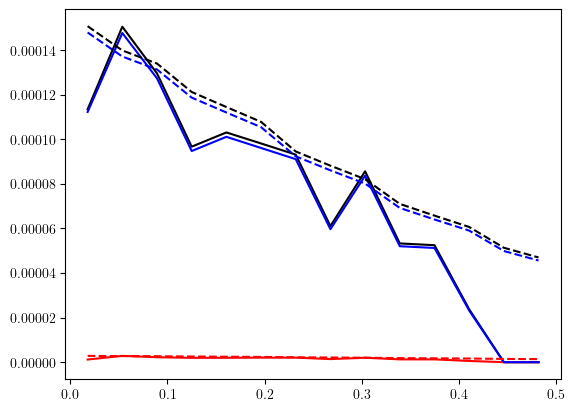

In [68]:
plt.figure()
plt.plot(zcen_cv_array, ngal_cv_array, color='k')
plt.plot(zcen_cv_array, ncen_cv_array, color='r')
plt.plot(zcen_cv_array, nsat_cv_array, color='b')

plt.plot(zcen_cv_array, ngal_cv_array_th, ls='--', color='k')
plt.plot(zcen_cv_array, ncen_cv_array_th, ls='--', color='r')
plt.plot(zcen_cv_array, nsat_cv_array_th, ls='--', color='b')



# 

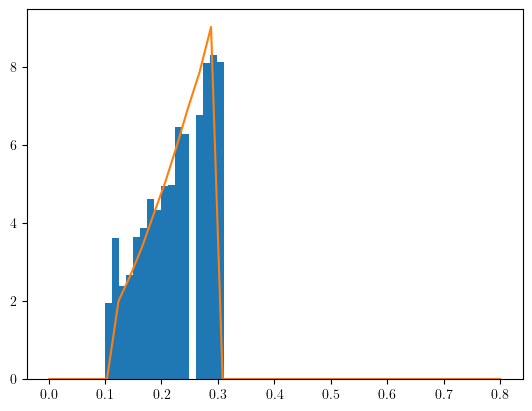

In [62]:
# ncen_cv_array
# nsat_cv_array
plt.figure()
_ = plt.hist(gal_z_all, density=True, range=(0.1, 0.31), bins=17)
plt.plot(zarray_lens, nz_lens[0])



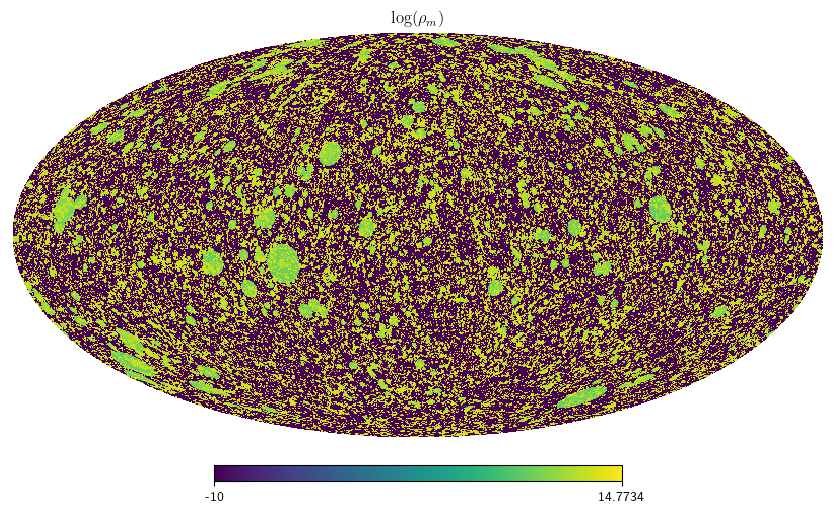

In [21]:
hp.mollview(np.log10(map_rhom+1e-10), title=fr'$\log(\rho_m)$')


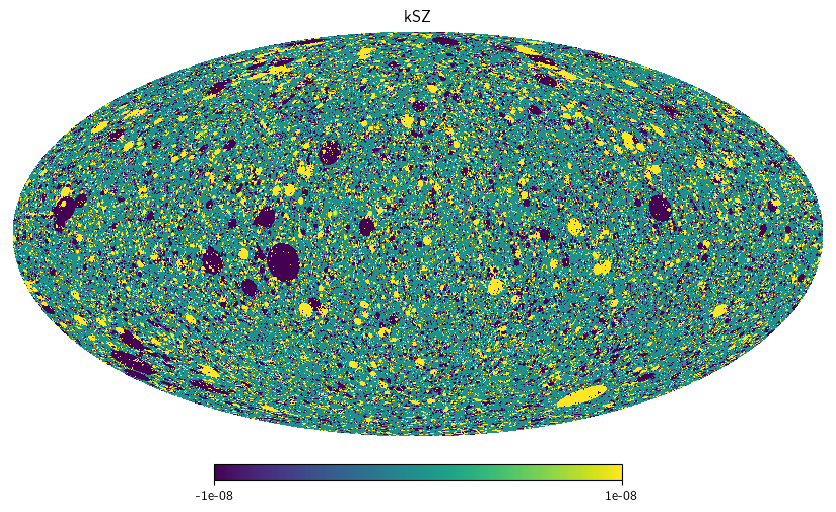

In [23]:
hp.mollview((map_ksz), title=fr'kSZ', min=-1e-8, max=1e-8)


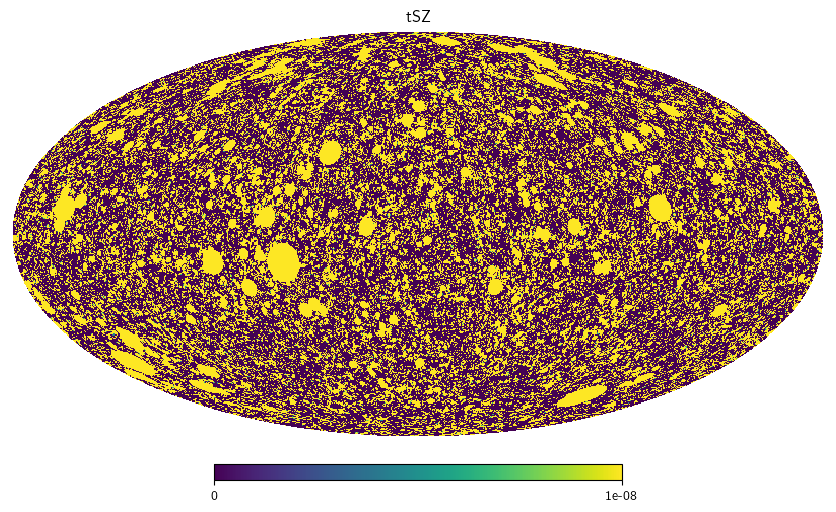

In [24]:
hp.mollview((map_ymap), title=fr'tSZ', min=0, max=1e-8)


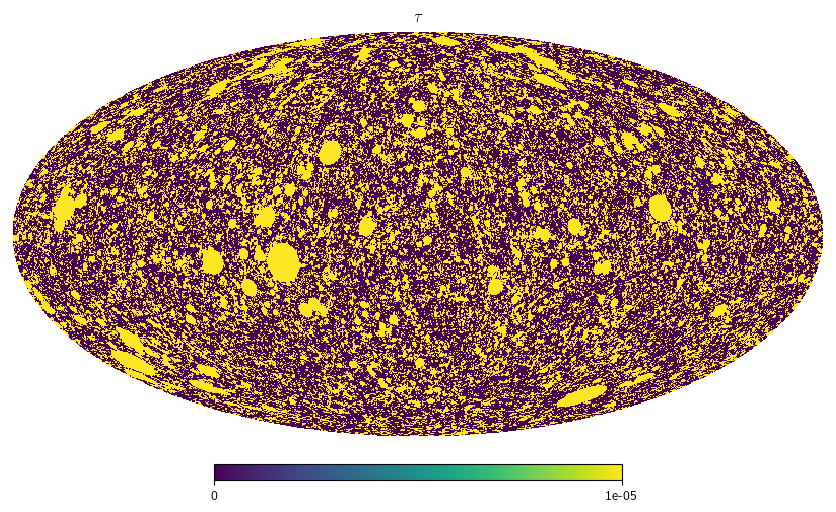

In [25]:
hp.mollview((map_tau), title=fr'$\tau$', min=0, max=1e-5)


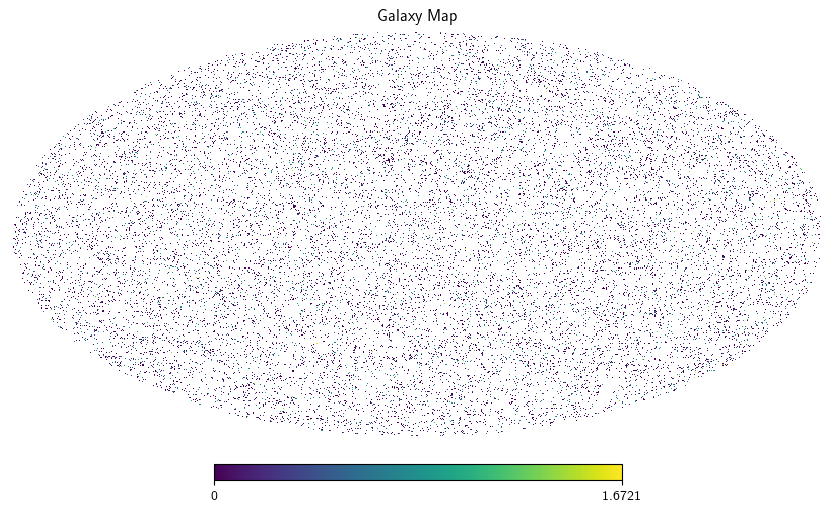

In [107]:
ra_all[ind_maxM], dec_all[ind_maxM], z_all[ind_maxM], M200c_all[ind_maxM], vlos_all[ind_maxM]


(np.float64(257.9637946613002),
 np.float64(6.249168325508876),
 np.float64(0.2755194),
 np.float64(2041099992432640.0),
 np.float64(298.4158020019531))

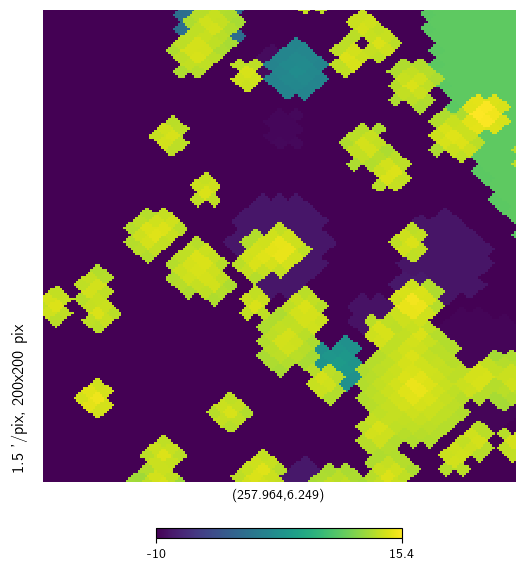

In [108]:
hp.gnomview(np.log10(map_rhom+1e-10), title='', rot=(ra_all[ind_maxM], dec_all[ind_maxM]))




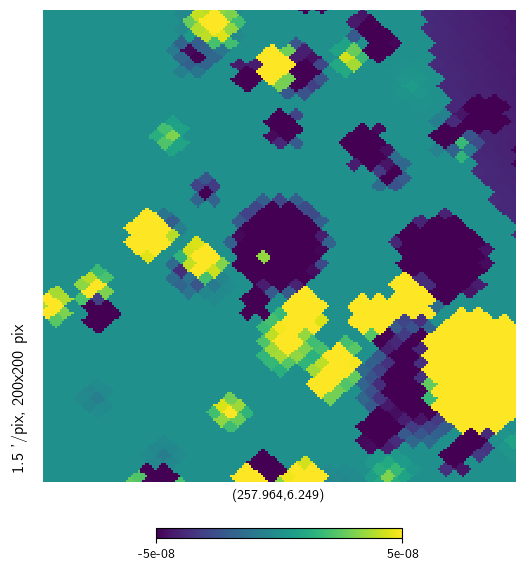

In [109]:
hp.gnomview(map_ksz, title='', min=-5e-8, max=5e-8, rot=(ra_all[ind_maxM], dec_all[ind_maxM]))




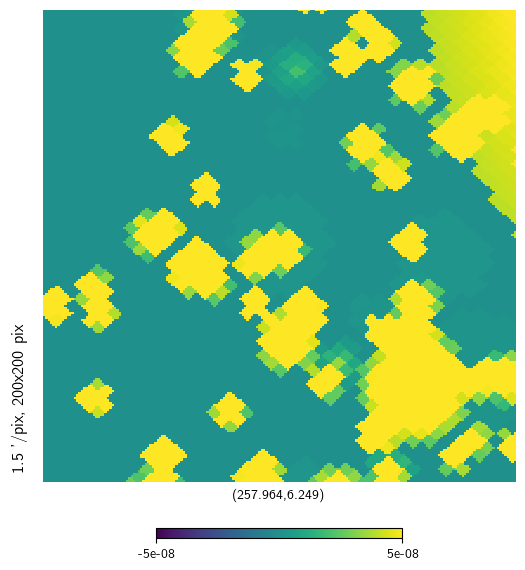

In [110]:
hp.gnomview(map_ymap, title='', min=-5e-8, max=5e-8, rot=(ra_all[ind_maxM], dec_all[ind_maxM]))




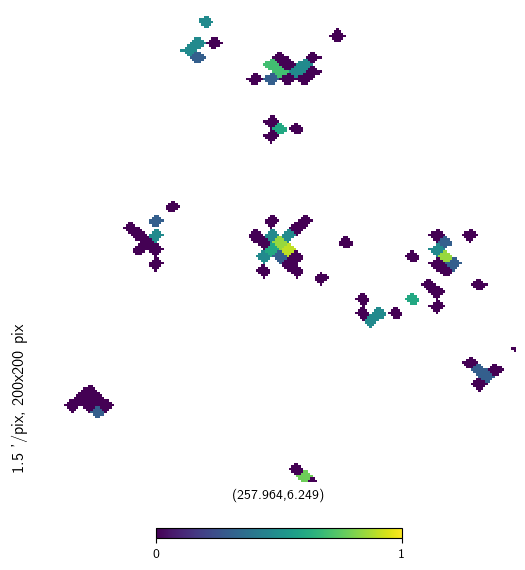

In [112]:
hp.gnomview(np.log10(map_gal), title='', rot=(ra_all[ind_maxM], dec_all[ind_maxM]), min=0, max=np.log10(10))




(100, 1000)

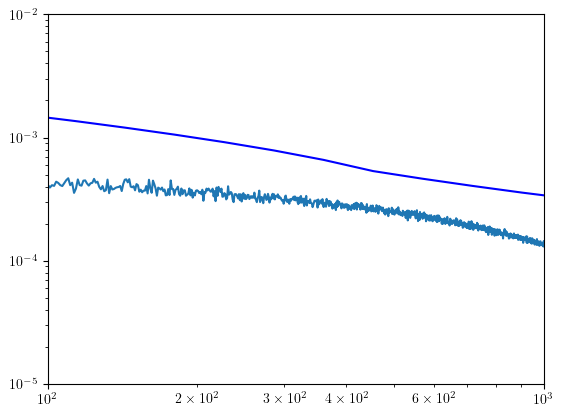

(5.249168325508876, 7.249168325508876)

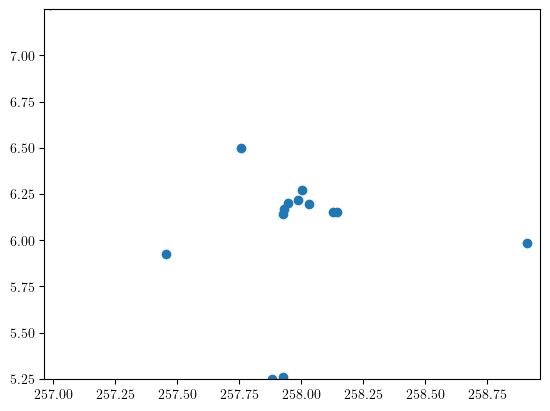

In [130]:
plt.figure()
plt.scatter(gal_ra_all, gal_dec_all)
plt.xlim(ra_all[ind_maxM] - 1, ra_all[ind_maxM] + 1)
plt.ylim(dec_all[ind_maxM] - 1, dec_all[ind_maxM] + 1)



In [131]:
indsel_zg = np.where((gal_ra_all > ra_all[ind_maxM] - 3) & (gal_ra_all < ra_all[ind_maxM] + 3) & (gal_dec_all > dec_all[ind_maxM] - 3) & (gal_dec_all < dec_all[ind_maxM] + 3))[0]
print(gal_z_all[indsel_zg],z_all[ind_maxM])




[0.3806728 0.3806728 0.3806728 0.3806728 0.3806728 0.3806728 0.3806728
 0.3806728 0.3806728 0.3806728 0.3806728 0.3647147 0.3647147 0.3647147
 0.3647147 0.3647147 0.3647147 0.3647147 0.3647147 0.3647147 0.3647147
 0.3647147 0.3647147 0.3647147 0.3647147 0.3647147 0.3647147 0.3647147
 0.3647147 0.3647147 0.3647147 0.3647147 0.3647147 0.3647147 0.3490879
 0.3337802 0.3337802 0.3337802 0.3337802 0.3337802 0.3337802 0.3337802
 0.2896598 0.2896598 0.2896598 0.2896598 0.2896598 0.2896598 0.2896598
 0.2896598 0.2755194 0.2755194 0.2755194 0.2755194 0.2755194 0.2755194
 0.2755194 0.2755194 0.2755194 0.2755194 0.2755194 0.2755194 0.261646
 0.261646  0.261646  0.261646  0.261646  0.261646  0.261646  0.261646
 0.261646  0.2480309 0.2480309 0.2480309 0.2480309 0.2480309 0.2346654
 0.2346654 0.2346654 0.2346654 0.2346654 0.2346654 0.2346654 0.2346654
 0.2346654 0.2346654 0.2346654 0.2346654 0.2346654 0.2346654 0.2086514
 0.1835434 0.1835434 0.1835434 0.113126  0.113126  0.113126 ] 0.2755194


In [39]:
import healpy as hp
from tqdm import tqdm
zmax_maps = 0.2
# snap_num = 82
nside = 1024
map_rhom_final = np.zeros(12 * nside**2, dtype=np.float32)
map_ymap_final = np.zeros(12 * nside**2, dtype=np.float32)
map_ksz_final = np.zeros(12 * nside**2, dtype=np.float32)
map_tau_final = np.zeros(12 * nside**2, dtype=np.float32)
map_gal_final = np.zeros(12 * nside**2, dtype=np.float32)
for snap_num in tqdm(range(82, 99)):
    ind_snapnum = np.where(snap_num_all == snap_num)[0]
    zval = zval_all[ind_snapnum][0]
    # print(zval)
    ldir_maps = '/mnt/ceph/users/spandey/paste_godmax/GODMAX/results/backlight_pkdgrav/'
    map_fname = f'{ldir_maps}/allmaps_sim_B12_nside{nside}_z{zval:.3f}_split{jdevice}of{Ndevices}.pkl'
    saved_data = pk.load(open(map_fname, 'rb'))
    mock_gals_all = saved_data['mock_gals_all']
    map_rhom = saved_data['map_rhom']
    map_ymap = saved_data['map_ymap']
    map_ksz = saved_data['map_ksz']
    map_tau = saved_data['map_tau']
    gal_ra_all = mock_gals_all[0][:,0]
    gal_dec_all = mock_gals_all[0][:,1]
    map_gal = np.zeros(12 * nside**2, dtype=np.float32)
    pix_gal = hp.ang2pix(nside, gal_ra_all, gal_dec_all, lonlat=True)
    np.add.at(map_gal, pix_gal, 1.)

    map_rhom_final += map_rhom
    map_ymap_final += map_ymap
    map_ksz_final += map_ksz
    map_tau_final += map_tau
    map_gal_final += map_gal



  0%|          | 0/17 [00:00<?, ?it/s]

0.1959877


  6%|▌         | 1/17 [00:01<00:20,  1.26s/it]

0.1835434


 12%|█▏        | 2/17 [00:02<00:22,  1.49s/it]

...

 88%|████████▊ | 15/17 [00:23<00:03,  1.65s/it]

0.02905384


 94%|█████████▍| 16/17 [00:24<00:01,  1.58s/it]

0.01923086


100%|██████████| 17/17 [00:26<00:00,  1.55s/it]


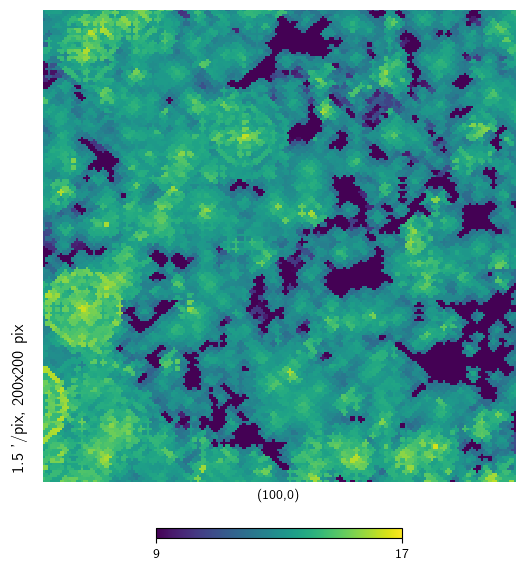

In [46]:
hp.gnomview(np.log10(map_rhom_final+1e-10), title='', rot=(100,0,0), min=9, max=17, reso=1.5)




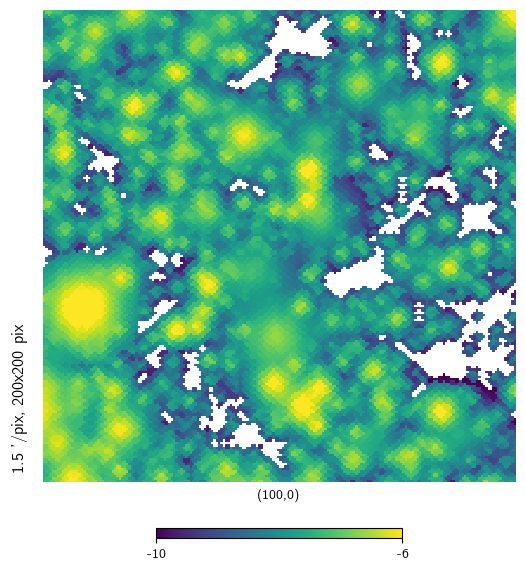

In [49]:
hp.gnomview(np.log10(map_ymap_final), title='', min=-10, max=-6, rot=(100,0,0))




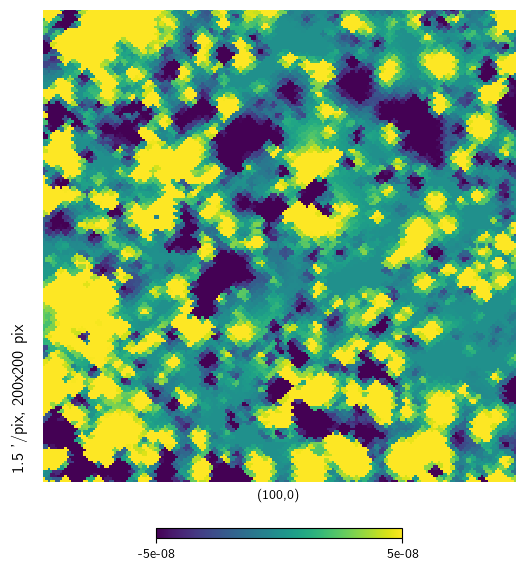

In [50]:
hp.gnomview(map_ksz_final, title='', min=-5e-8, max=5e-8, rot=(100,0,0))


